In [ ]:
import torch
import torchvision
from torchvision import transforms

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

In [ ]:
from modulefinder import test
#download dataset
train_ds = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.66MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 139kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.9MB/s]


In [ ]:
#data loader
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

In [ ]:
print(f'Train dataset size: {len(train_ds)}')
print(f'Test dataset size: {len(test_ds)}')

Train dataset size: 60000
Test dataset size: 10000


In [ ]:
rw_ds = datasets.FashionMNIST(root='./data', train=True, download=True)
img, label = rw_ds[0]
print("image:", img.size, "label:", label)

image: (28, 28) label: 9


In [ ]:
img, label = train_ds[0]
print("image:", img.shape, "label:", label)

image: torch.Size([1, 28, 28]) label: 9


In [ ]:
x, y = next(iter(train_loader))
print("batch x:", x.shape, "dtype:", x.dtype)
print("batch y:", y.shape, "min/max:", y.min().item(), y.max().item())

batch x: torch.Size([64, 1, 28, 28]) dtype: torch.float32
batch y: torch.Size([64]) min/max: 0 9


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class FashionCNN(nn.Module):
  def __init__(self, num_classes=10) -> None:
    super().__init__()                                                                #b,1,28,28
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1) #B,32, 14,14
    self.conv2 = nn.Conv2d(32,64, kernel_size=3, padding=1) #b, 64,7,7
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # /2

    self.fc1 = nn.Linear(64 * 7 * 7, 128) #64*7*7 -->128
    self.dropout = nn.Dropout(0.3)
    self.fc2 = nn.Linear(128, num_classes) #128 -> 10

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))

    x = torch.flatten(x,1)

    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x) # B,10

    return x

In [ ]:
model = FashionCNN().to(device)

In [ ]:
x,y = next(iter(train_loader))
x = x.to(device)

logits = model(x)
print(f'logits shape:{logits.shape}')

logits shape:torch.Size([64, 10])


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
@torch.no_grad()
def batch_acc(logits, y):
  pred = logits.argmax(dim=1, keepdim=True)
  return (pred == y).float().mean().item()

In [ ]:
#train one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss, acc, total = 0. , 0, 0

  for x,y in loader:
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

    total_loss += loss.item() * x.size(0)
    acc += batch_acc(logits, y)
    total += x.size(0)

  return total_loss / total, acc / total

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
  model.eval()

  total_loss, acc, total = 0. , 0, 0

  for x,y in loader:
    x, y = x.to(device), y.to(device)

    logits = model(x)
    loss = criterion(logits, y)

    total_loss += loss.item() * x.size(0)
    acc += batch_acc(logits, y)
    total += x.size(0)

  return total_loss / total, acc / total

In [ ]:
tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
te_loss, te_acc = evaluate(model, test_loader, criterion, device)

print(f'train loss: {tr_loss:.4f}, train acc: {tr_acc:.4f}')
print(f'test loss: {te_loss:.4f}, test acc: {te_acc:.4f}')

train loss: 0.4957, train acc: 0.0017
test loss: 0.3476, test acc: 0.0018


In [ ]:
history = {"train_loss": [], "train_acc":[], "test_loss":[], "test_acc":[]}
best_test_acc = -1.0

epochs = 7

for epoch in range(1, epochs + 1):
  tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
  te_loss, te_acc = evaluate(model, test_loader, criterion, device)

  history["train_loss"].append(tr_loss)
  history["train_acc"].append(tr_acc)
  history["test_loss"].append(te_loss)
  history["test_acc"].append(te_acc)

  if te_acc > best_test_acc:
    best_test_acc = te_acc
    torch.save(model.state_dict(), "best_fashioncnn.pt")

  print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {te_loss:.4f} acc {te_acc:.4f} | "
          f"best {best_test_acc:.4f}")

Epoch 01 | train loss 0.3258 acc 0.0018 | val loss 0.3027 acc 0.0018 | best 0.0018
Epoch 02 | train loss 0.2793 acc 0.0018 | val loss 0.2672 acc 0.0018 | best 0.0018
Epoch 03 | train loss 0.2475 acc 0.0018 | val loss 0.2572 acc 0.0018 | best 0.0018
Epoch 04 | train loss 0.2236 acc 0.0018 | val loss 0.2475 acc 0.0018 | best 0.0018
Epoch 05 | train loss 0.2043 acc 0.0018 | val loss 0.2425 acc 0.0018 | best 0.0018
Epoch 06 | train loss 0.1873 acc 0.0018 | val loss 0.2413 acc 0.0018 | best 0.0018
Epoch 07 | train loss 0.1687 acc 0.0018 | val loss 0.2315 acc 0.0018 | best 0.0018


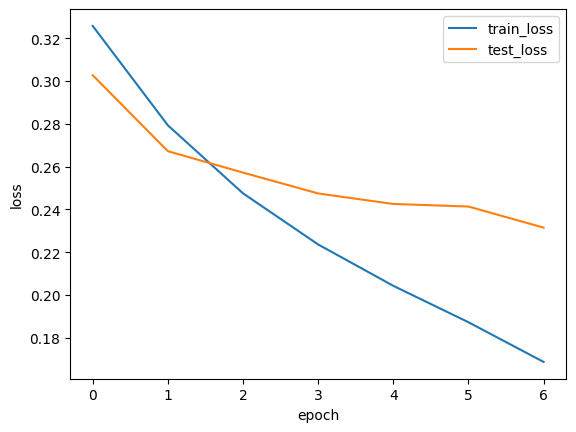

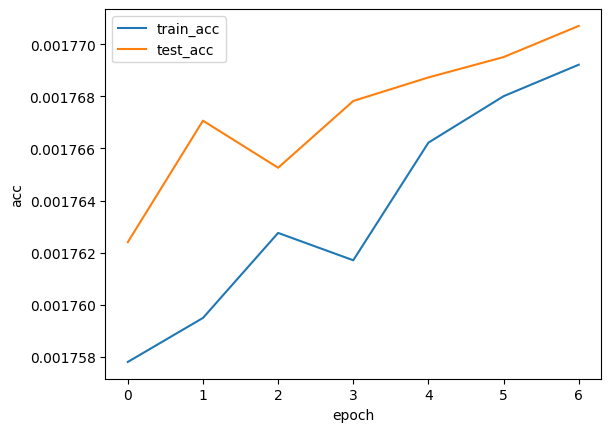

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["test_loss"], label="test_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["test_acc"], label="test_acc")
plt.xlabel("epoch")
plt.ylabel("acc")
plt.legend()
plt.show()

In [ ]:
classes = train_ds.classes

In [ ]:
import matplotlib.pyplot as plt

model.eval()

x,y = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
  logits = model(x)
  preds = logits.argmax(dim=1)

x = x.cpu()
preds = preds.cpu()

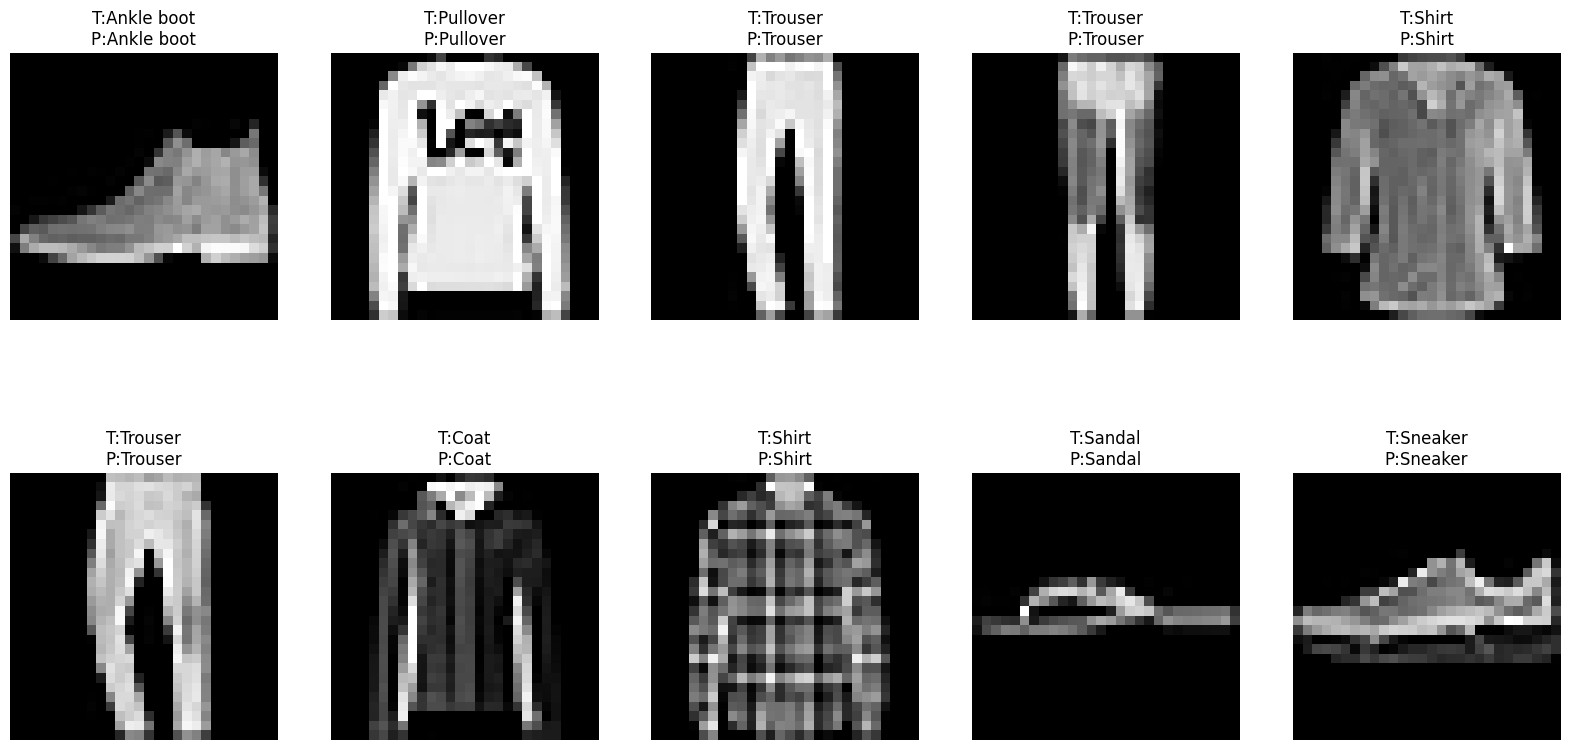

In [ ]:
plt.figure(figsize=(20,10))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x[i].squeeze(), cmap='gray')

  true_label = classes[y[i]]
  pred_label = classes[preds[i]]

  plt.title(f"T:{true_label}\nP:{pred_label}")
  plt.axis("off")

plt.show()